# WOM Compensation Analysis

Notebook for analyzing NetLogo BehaviorSpace results of the WOM compensation experiment.

Expected input: `table.csv`


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"]=(8,5)

df=pd.read_csv("./experiments/e5/table.csv", skiprows=6)
print(df.shape)
df.head()


(3240, 28)


,[run number],number-of-shoppers,reward-cycles,reward-duration,withdrawal-duration,low-reward-salience,high-reward-salience,wom-on?,network-topology,network-degree,...,high-reward-withdrawal-drop,high-reward-retention-ratio,"persistence-index ""high-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""high-salience""","mean-opinion ""high-salience""",wom-speaker-share,wom-receiver-share,mean-absolute-wom-opinion-change,mean-network-degree
0,5,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.400250,0.546972,0.073167,0.414162,0.430625,0.076877,0.0,0.0,0.0,4.0
1,9,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.419990,0.528079,0.065885,0.413795,0.416250,0.079390,0.0,0.0,0.0,4.0
2,2,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.409521,0.537112,0.079187,0.413643,0.418625,0.075161,0.0,0.0,0.0,4.0
3,4,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.406615,0.543685,0.079719,0.411437,0.434625,0.079148,0.0,0.0,0.0,4.0
4,7,1200,1,60,80,0.15,0.75,False,small-world,4,...,0.420958,0.524251,0.071458,0.410567,0.415375,0.078853,0.0,0.0,0.0,4.0


## Inspect columns

In [6]:
print(sorted(df.columns.tolist()))

['[run number]', '[step]', 'choice-rate "high-salience" "baseline"', 'choice-rate "high-salience" "reward"', 'confidence-bound', 'final-withdrawal-choice-rate "high-salience"', 'high-reward-retention-ratio', 'high-reward-salience', 'high-reward-withdrawal-drop', 'low-reward-salience', 'mean-absolute-wom-opinion-change', 'mean-habit "high-salience"', 'mean-intrinsic-motivation "high-salience"', 'mean-network-degree', 'mean-opinion "high-salience"', 'network-degree', 'network-topology', 'number-of-shoppers', 'persistence-index "high-salience"', 'purchase-deliberation-mode', 'reward-cycles', 'reward-duration', 'rewiring-probability', 'show-network?', 'withdrawal-duration', 'wom-on?', 'wom-receiver-share', 'wom-speaker-share']


## Basic statistics

In [7]:
numeric = df.select_dtypes(include="number")
df.describe()

,[run number],number-of-shoppers,reward-cycles,reward-duration,withdrawal-duration,low-reward-salience,high-reward-salience,network-degree,rewiring-probability,confidence-bound,...,high-reward-withdrawal-drop,high-reward-retention-ratio,"persistence-index ""high-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""high-salience""","mean-opinion ""high-salience""",wom-speaker-share,wom-receiver-share,mean-absolute-wom-opinion-change,mean-network-degree
count,3240.000000,3240.0,3240.0,3240.0,3240.0,3.240000e+03,3240.00,3240.00000,3240.0,3240.000000,...,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000
mean,1620.500000,1200.0,1.0,60.0,80.0,1.500000e-01,0.75,8.00000,0.1,0.633333,...,0.410116,0.536197,0.073807,0.410380,0.427726,0.089408,0.123582,0.131686,0.004906,7.994361
std,935.451763,0.0,0.0,0.0,0.0,2.775986e-17,0.00,3.26649,0.0,0.286788,...,0.008549,0.009727,0.007690,0.006226,0.012526,0.017921,0.185334,0.204374,0.007237,3.262674
min,1.000000,1200.0,1.0,60.0,80.0,1.500000e-01,0.75,4.00000,0.1,0.300000,...,0.380135,0.501925,0.047156,0.387292,0.387500,0.059630,0.000000,0.000000,0.000000,3.711667
25%,810.750000,1200.0,1.0,60.0,80.0,1.500000e-01,0.75,4.00000,0.1,0.300000,...,0.404661,0.529500,0.068667,0.406135,0.418750,0.076771,0.000000,0.000000,0.000000,4.000000
50%,1620.500000,1200.0,1.0,60.0,80.0,1.500000e-01,0.75,8.00000,0.1,0.600000,...,0.410443,0.535996,0.073635,0.410386,0.427250,0.082751,0.025000,0.023750,0.000884,8.000000
75%,2430.250000,1200.0,1.0,60.0,80.0,1.500000e-01,0.75,12.00000,0.1,1.000000,...,0.416138,0.542567,0.078927,0.414545,0.435875,0.096061,0.130417,0.126042,0.005700,11.965000
max,3240.000000,1200.0,1.0,60.0,80.0,1.500000e-01,0.75,12.00000,0.1,1.000000,...,0.437948,0.572295,0.106438,0.435529,0.477250,0.139696,0.625000,0.693333,0.026208,12.456667


## Average withdrawal performance

In [8]:
target = 'final-withdrawal-choice-rate "high-salience"'

group_cols=[
"wom-on?",
"network-topology",
"network-degree",
"purchase-deliberation-mode",
"confidence-bound"
]

summary=(df.groupby(group_cols)[target]
           .agg(["mean","std","count"])
           .reset_index()
           .sort_values("mean",ascending=False))

summary.head(20)


,wom-on?,network-topology,network-degree,purchase-deliberation-mode,confidence-bound,mean,std,count
84,True,random,12,high-involvement,0.3,0.486600,0.008146,30
104,True,small-world,12,high-involvement,1.0,0.483345,0.007169,30
85,True,random,12,high-involvement,0.6,0.482938,0.010477,30
86,True,random,12,high-involvement,1.0,0.482493,0.009078,30
102,True,small-world,12,high-involvement,0.3,0.482443,0.007857,30
103,True,small-world,12,high-involvement,0.6,0.481766,0.009740,30
96,True,small-world,8,high-involvement,0.3,0.481759,0.007550,30
66,True,preferential-attachment,12,high-involvement,0.3,0.481376,0.010020,30
97,True,small-world,8,high-involvement,0.6,0.481204,0.007659,30
62,True,preferential-attachment,8,high-involvement,1.0,0.481102,0.009308,30


## WOM compensation

In [9]:
wom=summary[summary["wom-on?"]==True].copy()
base=summary[summary["wom-on?"]==False].copy()

join_cols=["network-topology","network-degree","purchase-deliberation-mode","confidence-bound"]

merged=wom.merge(base[join_cols+["mean"]],
                 on=join_cols,
                 suffixes=("_wom","_base"))

merged["compensation"]=merged["mean_wom"]-merged["mean_base"]
merged.sort_values("compensation",ascending=False).head(20)


,wom-on?,network-topology,network-degree,purchase-deliberation-mode,confidence-bound,mean_wom,std,count,mean_base,compensation
4,True,small-world,12,high-involvement,0.3,0.482443,0.007857,30,0.469727,0.012716
0,True,random,12,high-involvement,0.3,0.486600,0.008146,30,0.474403,0.012197
2,True,random,12,high-involvement,0.6,0.482938,0.010477,30,0.471623,0.011315
10,True,small-world,8,high-involvement,1.0,0.480860,0.008655,30,0.469734,0.011126
1,True,small-world,12,high-involvement,1.0,0.483345,0.007169,30,0.472757,0.010588
11,True,random,8,high-involvement,0.3,0.480512,0.007803,30,0.470092,0.010421
16,True,preferential-attachment,8,high-involvement,0.3,0.479389,0.007849,30,0.469260,0.010128
8,True,small-world,8,high-involvement,0.6,0.481204,0.007659,30,0.472015,0.009190
15,True,random,8,high-involvement,0.6,0.479448,0.007759,30,0.470531,0.008917
3,True,random,12,high-involvement,1.0,0.482493,0.009078,30,0.473768,0.008725


## Heatmap

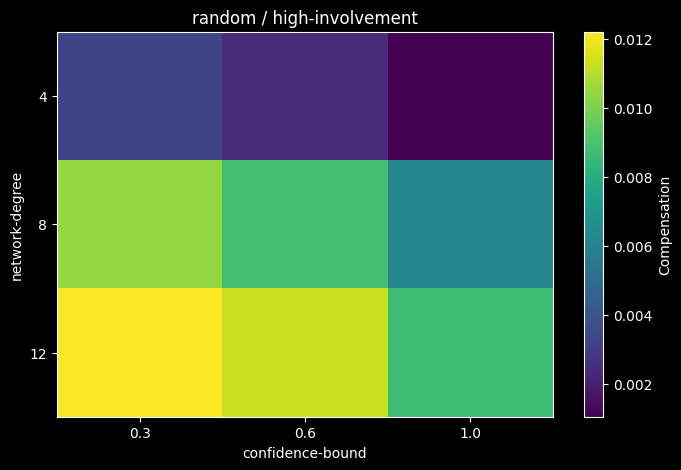

In [10]:
topology="random"
mode="high-involvement"

tmp=merged[(merged["network-topology"]==topology) &
           (merged["purchase-deliberation-mode"]==mode)]

pivot=tmp.pivot(index="network-degree",
                columns="confidence-bound",
                values="compensation")

fig,ax=plt.subplots()
im=ax.imshow(pivot.values,aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("confidence-bound")
ax.set_ylabel("network-degree")
ax.set_title(f"{topology} / {mode}")
plt.colorbar(im,label="Compensation")
plt.show()


## Ranking

In [11]:
merged.sort_values("compensation",ascending=False).head(30)

,wom-on?,network-topology,network-degree,purchase-deliberation-mode,confidence-bound,mean_wom,std,count,mean_base,compensation
4,True,small-world,12,high-involvement,0.3,0.482443,0.007857,30,0.469727,0.012716
0,True,random,12,high-involvement,0.3,0.486600,0.008146,30,0.474403,0.012197
2,True,random,12,high-involvement,0.6,0.482938,0.010477,30,0.471623,0.011315
10,True,small-world,8,high-involvement,1.0,0.480860,0.008655,30,0.469734,0.011126
1,True,small-world,12,high-involvement,1.0,0.483345,0.007169,30,0.472757,0.010588
11,True,random,8,high-involvement,0.3,0.480512,0.007803,30,0.470092,0.010421
16,True,preferential-attachment,8,high-involvement,0.3,0.479389,0.007849,30,0.469260,0.010128
8,True,small-world,8,high-involvement,0.6,0.481204,0.007659,30,0.472015,0.009190
15,True,random,8,high-involvement,0.6,0.479448,0.007759,30,0.470531,0.008917
3,True,random,12,high-involvement,1.0,0.482493,0.009078,30,0.473768,0.008725


## Interaction plot

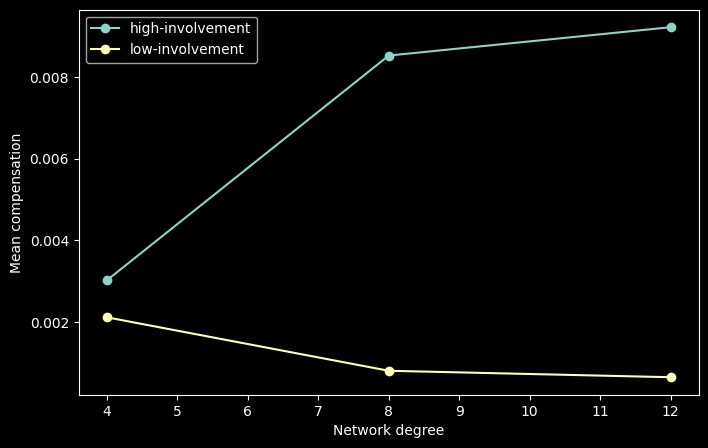

In [12]:
fig,ax=plt.subplots()

for mode,g in merged.groupby("purchase-deliberation-mode"):
    d=g.groupby("network-degree")["compensation"].mean()
    ax.plot(d.index,d.values,marker="o",label=mode)

ax.set_xlabel("Network degree")
ax.set_ylabel("Mean compensation")
ax.legend()
plt.show()


## Conclusions

Answer:

1. Which topology performs best?
2. Does high-involvement outperform low-involvement?
3. How does network degree affect compensation?
4. How does confidence-bound affect compensation?
5. Top-10 configurations.
